# Notebook 05 — Full Campus Navigation Demo
Combines ResNet50 + YOLOv8 and gives walking directions

## Cell 1 — Load both models

In [1]:
import torch, torch.nn as nn
from torchvision import models, transforms
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import networkx as nx
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load ResNet50
ckpt        = torch.load("resnet50_campus.pth", map_location=device)
classes     = ckpt["classes"]
NUM_CLASSES = ckpt["num_classes"]
resnet      = models.resnet50(pretrained=False)
resnet.fc   = nn.Sequential(
    nn.Linear(2048,512), nn.ReLU(),
    nn.Dropout(0.4), nn.Linear(512,NUM_CLASSES))
resnet.load_state_dict(ckpt["model_state_dict"])
resnet = resnet.to(device)
resnet.eval()

# Load YOLOv8
yolo = YOLO("runs/detect/campus_signs/weights/best.pt")

tf = transforms.Compose([
    transforms.Resize((224,224)), transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

print(f"✓ ResNet50 loaded — {NUM_CLASSES} campus classes")
print(f"✓ YOLOv8 loaded — sign detector ready")
print(f"\nCampus classes: {classes}")

c:\Users\darwa\OneDrive\Desktop\campus_navigation_project update\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\darwa\OneDrive\Desktop\campus_navigation_project update\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✓ ResNet50 loaded — 6 campus classes
✓ YOLOv8 loaded — sign detector ready

Campus classes: ['bartels_exterior', 'bergami_exterior', 'dodds_exterior', 'john_and_leona_exterior', 'kaplan_exterior', 'maxy_exterior']


## Cell 2 — Build campus navigation graph

In [2]:
# Build the campus graph
# Nodes = campus location class names (same as your folder names)
# Edges = walking connections between locations
# Weight = estimated walking seconds

G = nx.Graph()

# Add your campus connections here based on your actual buildings
# Format: G.add_edge("from_location", "to_location", weight=seconds)
G.add_edge("dodds_exterior",        "kaplan_exterior",       weight=60)
G.add_edge("kaplan_exterior",       "kaplan_floor2_room207", weight=40)
G.add_edge("kaplan_exterior",       "kaplan_floor3_lab301",  weight=55)
G.add_edge("kaplan_exterior",       "library_exterior",      weight=90)
G.add_edge("library_exterior",      "dodds_exterior",        weight=70)
G.add_edge("kaplan_floor2_room207", "kaplan_floor3_lab301",  weight=20)

print("✓ Campus graph built")
print(f"  Locations (nodes): {list(G.nodes())}")
print(f"  Connections (edges): {G.number_of_edges()}")

✓ Campus graph built
  Locations (nodes): ['dodds_exterior', 'kaplan_exterior', 'kaplan_floor2_room207', 'kaplan_floor3_lab301', 'library_exterior']
  Connections (edges): 6


## Cell 3 — Parse class name into building / floor / room

In [3]:
def parse_location(class_name):
    """Converts 'kaplan_floor2_room207' to
       ('Kaplan Hall', 'Floor 2', 'Room 207')"""
    parts = class_name.split("_")
    building_map = {
        "dodds"  : "Robert B. Dodds Hall",
        "kaplan" : "Kaplan Hall",
        "library": "Marvin K. Peterson Library",
        "bergami": "Bergami Learning Center",
    }
    building = building_map.get(parts[0], parts[0].title())
    floor, room = None, None
    if len(parts) > 1 and parts[1].startswith("floor"):
        floor = "Floor " + parts[1].replace("floor","")
        if len(parts) > 2:
            room = " ".join(parts[2:]).replace("_"," ").title()
    elif len(parts) > 1:
        room = " ".join(parts[1:]).replace("_"," ").title()
    return building, floor, room

# Test it
for cls in classes:
    b, f, r = parse_location(cls)
    print(f"  {cls:35s} → {b}" +
          (f" · {f}" if f else "") +
          (f" · {r}" if r else ""))

  bartels_exterior                    → Bartels · Exterior
  bergami_exterior                    → Bergami Learning Center · Exterior
  dodds_exterior                      → Robert B. Dodds Hall · Exterior
  john_and_leona_exterior             → John · And Leona Exterior
  kaplan_exterior                     → Kaplan Hall · Exterior
  maxy_exterior                       → Maxy · Exterior


## Cell 4 — Full navigate function

In [4]:
def navigate(photo_path, destination_class):
    print(f"\n{'='*60}")
    print(f"  Photo : {photo_path}")
    print(f"  Going to : {destination_class}")
    print(f"{'='*60}")

    # ── ResNet50: classify location ───────────────────────────
    img_pil    = Image.open(photo_path).convert("RGB")
    img_tensor = tf(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        out   = resnet(img_tensor)
        probs = torch.softmax(out, dim=1)
        conf, idx = probs.max(dim=1)
    location   = classes[idx.item()]
    confidence = conf.item()

    # ── YOLOv8: detect signs ──────────────────────────────────
    yolo_results = yolo(photo_path, conf=0.3, verbose=False)

    # ── Display: image + YOLOv8 boxes ────────────────────────
    annotated = yolo_results[0].plot()
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    ax1.imshow(img_pil)
    b, f, r = parse_location(location)
    loc_str = b + (f"\n{f}" if f else "") + (f" · {r}" if r else "")
    ax1.set_title(f"ResNet50 Prediction\n{loc_str}\n({confidence:.0%} confident)",
                  fontsize=11, fontweight="bold", color="green")
    ax1.axis("off")

    ax2.imshow(annotated[:,:,::-1])
    n_det = len(yolo_results[0].boxes)
    ax2.set_title(f"YOLOv8 Sign Detection\n{n_det} sign(s) detected",
                  fontsize=11, fontweight="bold", color="blue")
    ax2.axis("off")

    plt.suptitle("Campus Navigation System — Dual Model Output",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("navigation_output.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Print location ─────────────────────────────────────────
    print(f"\n  ResNet50 → {location}  ({confidence:.0%})")
    print(f"  Building : {b}")
    if f: print(f"  Floor    : {f}")
    if r: print(f"  Room     : {r}")

    for box in yolo_results[0].boxes:
        lbl = yolo.names[int(box.cls[0])]
        c   = float(box.conf[0])
        print(f"  YOLOv8   → {lbl}  ({c:.0%})")

    # ── Navigate ────────────────────────────────────────────────
    if location not in G or destination_class not in G:
        print(f"\n  Add these nodes to the graph in Cell 2")
        return

    path = nx.shortest_path(G, location, destination_class, weight="weight")
    secs = nx.shortest_path_length(G, location, destination_class, weight="weight")

    print(f"\n  Walking route  ({secs//60}m {secs%60}s):")
    for i, node in enumerate(path, 1):
        b2, f2, r2 = parse_location(node)
        label = b2 + (f" · {f2}" if f2 else "") + (f" · {r2}" if r2 else "")
        mark  = "► Start" if i==1 else ("✓ Destination" if i==len(path) else f"  Step {i}")
        print(f"    {mark}: {label}")

    print("\n✓ Saved as navigation_output.png")

## Cell 5 — Run the demo


  Photo : data_yolo/images/val/IMG20260323142741.jpg
  Going to : maxy_exterior


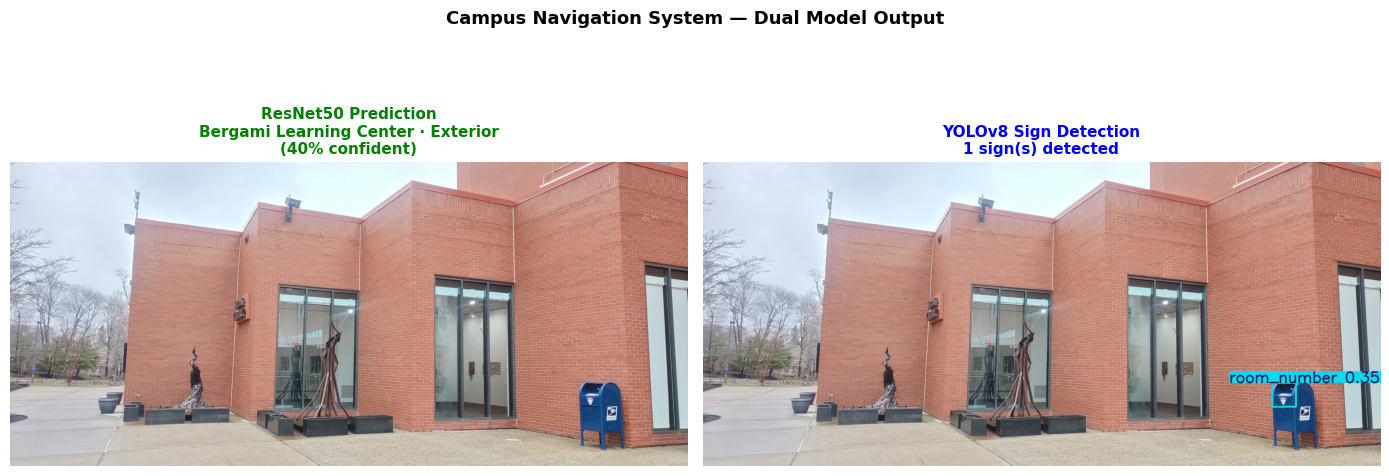


  ResNet50 → bergami_exterior  (40%)
  Building : Bergami Learning Center
  Room     : Exterior
  YOLOv8   → room_number  (35%)

  Add these nodes to the graph in Cell 2


In [5]:
# Change this to any photo from your campus
# It can be a new photo NOT in your training data
test_photos = os.listdir("data_yolo/images/val")
if test_photos:
    demo_photo = f"data_yolo/images/val/{test_photos[0]}"
else:
    demo_photo = "your_test_photo.jpg"   # replace with your photo path

# Change destination to any class name from your folder structure
destination = classes[-1]   # automatically picks last class

navigate(
    photo_path       = demo_photo,
    destination_class= destination
)